### Changing optimization parameters
It's time to get your hands dirty with optimization. You'll now try optimizing a model at a very low learning rate, a very high learning rate, and a "just right" learning rate. You'll want to look at the results after running this exercise, remembering that a low value for the loss function is good.

For these exercises, we've pre-loaded the predictors and target values from your previous classification models (predicting who would survive on the Titanic). You'll want the optimization to start from scratch every time you change the learning rate, to give a fair comparison of how each learning rate did in your results. So we have created a function get_new_model() that creates an unoptimized model to optimize.

- Import SGD from tensorflow.keras.optimizers.
- Create a list of learning rates to try optimizing with called lr_to_test. The learning rates in it should be .000001, 0.01, and 1.
- Using a for loop to iterate over lr_to_test:
    - Use the get_new_model() function to build a new, unoptimized model.
    - Create an optimizer called my_optimizer using the SGD() constructor with keyword argument lr=lr.
    - Compile your model. Set the optimizer parameter to be the SGD object you created above, and because this is a classification problem, use 'categorical_crossentropy' for the loss parameter.
    - Fit your model using the predictors and target.

In [ ]:
def get_new_model(input_shape=input_shape):
    model = Sequential()
    
    model.add(Dense(100, activation='relu', input_shape=input_shape))
    
    model.add(Dense(100, activation='relu'))
    
    model.add(Dense(2, activation='softmax'))
    
    return (model)

In [ ]:
# Import the SGD optimizer
from tensorflow.keras.optimizers import SGD

# Create list of learning rates: lr_to_test
lr_to_test = [.000001, 0.01, 1]

# Loop over learning rates
for lr in lr_to_test:
    print('\n\nTesting model with learning rate: %f\n'%lr )
    
    # Build new model to test, unaffected by previous models
    model = get_new_model()
    
    # Create SGD optimizer with specified learning rate: my_optimizer
    my_optimizer = SGD(lr=lr)
    
    # Compile the model
    model.compile(optimizer=my_optimizer, loss='categorical_crossentropy')
    
    # Fit the model
    model.fit(predictors, target)


Testing model with learning rate: 0.000001


 1/28 [>.............................] - ETA: 6s - loss: 1.0891
28/28 [==============================] - 0s 665us/step - loss: 1.2122


Testing model with learning rate: 0.010000


 1/28 [>.............................] - ETA: 4s - loss: 2.9479
28/28 [==============================] - 0s 621us/step - loss: 1.6476


Testing model with learning rate: 1.000000


 1/28 [>.............................] - ETA: 7s - loss: 2.8393
28/28 [==============================] - 0s 634us/step - loss: 185739.2656

## Evaluating model accuracy on validation dataset
Now it's your turn to monitor model accuracy with a validation data set. A model definition has been provided as model. Your job is to add the code to compile it and then fit it. You'll check the validation score in each epoch.

- Compile your model using 'adam' as the optimizer and 'categorical_crossentropy' for the loss. To see what fraction of predictions are correct (the accuracy) in each epoch, specify the additional keyword argument metrics=['accuracy'] in model.compile().
- Fit the model using the predictors and target. Create a validation split of 30% (or 0.3). This will be reported in each epoch.

In [ ]:
# Save the number of columns in predictors: n_cols
n_cols = predictors.shape[1]
input_shape = (n_cols,)

# Specify the model
model = Sequential()
model.add(Dense(100, activation='relu', input_shape = input_shape))
model.add(Dense(100, activation='relu'))
model.add(Dense(2, activation='softmax'))

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Fit the model
hist = model.fit(predictors, target, validation_split=0.3)

 1/20 [>.............................] - ETA: 8s - loss: 0.6620 - accuracy: 0.8438
20/20 [==============================] - 1s 9ms/step - loss: 0.8769 - accuracy: 0.6533 - val_loss: 0.5612 - val_accuracy: 0.7425

### Early stopping: Optimizing the optimization
Now that you know how to monitor your model performance throughout optimization, you can use early stopping to stop optimization when it isn't helping any more. Since the optimization stops automatically when it isn't helping, you can also set a high value for epochs in your call to .fit(), as Dan showed in the video.

The model you'll optimize has been specified as model. As before, the data is pre-loaded as predictors and target.

- Import EarlyStopping from tensorflow.keras.callbacks.
- Compile the model, once again using 'adam' as the optimizer, 'categorical_crossentropy' as the loss function, and metrics=['accuracy'] to see the accuracy at each epoch.
- Create an EarlyStopping object called early_stopping_monitor. Stop optimization when the validation loss hasn't improved for 2 epochs by specifying the patience parameter of EarlyStopping() to be 2.
- Fit the model using the predictors and target. Specify the number of epochs to be 30 and use a validation split of 0.3. In addition, pass [early_stopping_monitor] to the callbacks parameter.



In [ ]:
# Import EarlyStopping
from tensorflow.keras.callbacks import EarlyStopping

# Save the number of columns in predictors: n_cols
n_cols = predictors.shape[1]
input_shape = (n_cols,)

# Specify the model
model = Sequential()
model.add(Dense(100, activation='relu', input_shape = input_shape))
model.add(Dense(100, activation='relu'))
model.add(Dense(2, activation='softmax'))

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Define early_stopping_monitor
early_stopping_monitor = EarlyStopping(patience=2)

# Fit the model
model.fit(predictors,target, validation_split=0.3, epochs=30,callbacks=[early_stopping_monitor])
Epoch 1/30

 1/20 [>.............................] - ETA: 5s - loss: 2.0403 - accuracy: 0.5312
20/20 [==============================] - 0s 8ms/step - loss: 1.1620 - accuracy: 0.5538 - val_loss: 0.6357 - val_accuracy: 0.6642
Epoch 2/30

 1/20 [>.............................] - ETA: 0s - loss: 0.6762 - accuracy: 0.6250
20/20 [==============================] - 0s 2ms/step - loss: 0.8102 - accuracy: 0.6035 - val_loss: 0.5418 - val_accuracy: 0.7201
Epoch 3/30

 1/20 [>.............................] - ETA: 0s - loss: 0.6075 - accuracy: 0.7188
20/20 [==============================] - 0s 2ms/step - loss: 0.6470 - accuracy: 0.6677 - val_loss: 0.5886 - val_accuracy: 0.7388
Epoch 4/30

 1/20 [>.............................] - ETA: 0s - loss: 0.5998 - accuracy: 0.7500
20/20 [==============================] - 0s 2ms/step - loss: 0.6727 - accuracy: 0.6822 - val_loss: 0.6138 - val_accuracy: 0.7239
<keras.callbacks.History at 0x7fb97516a940>

Wonderful work! Because optimization will automatically stop when it is no longer helpful, it is okay to specify the maximum number of epochs as 30 rather than using the default of 10 that you've used so far. Here, it seems like the optimization stopped after 4 epochs.

## Experimenting with wider networks
Now you know everything you need to begin experimenting with different models!

A model called model_1 has been pre-loaded. You can see a summary of this model printed in the IPython Shell. This is a relatively small network, with only 10 units in each hidden layer.

In this exercise you'll create a new model called model_2 which is similar to model_1, except it has 100 units in each hidden layer.

After you create model_2, both models will be fitted, and a graph showing both models loss score at each epoch will be shown. We added the argument verbose=False in the fitting commands to print out fewer updates, since you will look at these graphically instead of as text.

Because you are fitting two models, it will take a moment to see the outputs after you hit run, so be patient.


- Create model_2 to replicate model_1, but use 100 nodes instead of 10 for the first two Dense layers you add with the 'relu' activation. Use 2 nodes for the Dense output layer with 'softmax' as the activation.
- Compile model_2 as you have done with previous models: Using 'adam' as the optimizer, 'categorical_crossentropy' for the loss, and metrics=['accuracy'].
- Hit 'Submit Answer' to fit both the models and visualize which one gives better results! Notice the keyword argument verbose=False in model.fit(): This prints out fewer updates, since you'll be evaluating the models graphically instead of through text.

In [ ]:
# Define early_stopping_monitor
early_stopping_monitor = EarlyStopping(patience=2)

# Create the new model: model_2
model_2 = Sequential()

# Add the first and second layers
model_2.add(Dense(100, activation='relu', input_shape=input_shape))
model_2.add(Dense(100, activation='relu'))

# Add the output layer
model_2.add(Dense(2, activation='softmax'))

# Compile model_2
model_2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Fit model_1
model_1_training = model_1.fit(predictors, target, epochs=15, validation_split=0.2, callbacks=[early_stopping_monitor], verbose=False)

# Fit model_2
model_2_training = model_2.fit(predictors, target, epochs=15, validation_split=0.2, callbacks=[early_stopping_monitor], verbose=False)

# Create the plot
plt.plot(model_1_training.history['val_loss'], 'r', model_2_training.history['val_loss'], 'b')
plt.xlabel('Epochs')
plt.ylabel('Validation score')
plt.show()

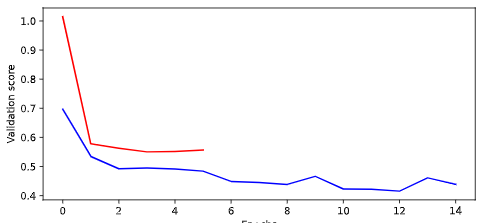

## Adding layers to a network
You've seen how to experiment with wider networks. In this exercise, you'll try a deeper network (more hidden layers).

Once again, you have a baseline model called model_1 as a starting point. It has 1 hidden layer, with 10 units. You can see a summary of that model's structure printed out. You will create a similar network with 3 hidden layers (still keeping 10 units in each layer).

This will again take a moment to fit both models, so you'll need to wait a few seconds to see the results after you run your code.

- Specify a model called model_2 that is like model_1, but which has 3 hidden layers of 10 units instead of only 1 hidden layer.
    - Use input_shape to specify the input shape in the first hidden layer.
    - Use 'relu' activation for the 3 hidden layers and 'softmax' for the output layer, which should have 2 units.
- Compile model_2 as you have done with previous models: Using 'adam' as the optimizer, 'categorical_crossentropy' for the loss, and metrics=['accuracy'].
- Hit 'Submit Answer' to fit both the models and visualize which one gives better results!

In [ ]:
# The input shape to use in the first hidden layer
input_shape = (n_cols,)

# Create the new model: model_2
model_2 = Sequential()

# Add the first, second, and third hidden layers
model_2.add(Dense(10, activation='relu', input_shape=input_shape))
model_2.add(Dense(10, activation='relu'))
model_2.add(Dense(10, activation='relu'))

# Add the output layer
model_2.add(Dense(2, activation='softmax'))

# Compile model_2
model_2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Fit model 1
model_1_training = model_1.fit(predictors, target, epochs=15, validation_split=0.4, verbose=False)

# Fit model 2
model_2_training = model_2.fit(predictors, target, epochs=15, validation_split=0.4, verbose=False)

# Create the plot
plt.plot(model_1_training.history['val_loss'], 'r', model_2_training.history['val_loss'], 'b')
plt.xlabel('Epochs')
plt.ylabel('Validation score')
plt.show()

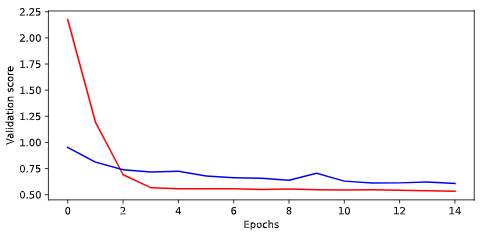